# dring input data overview

This notebook visualizes the public input files used by `dring`: per-band radial profiles and split opacity arrays.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
DATA = PROJECT_ROOT / "data"
print(PROJECT_ROOT)

/media/lhyang/SHAO_HPC/project_papper2/dring


## Per-band radial profiles

Each profile file contains `radius`, `intensity`, and `rms_error` for one wavelength band.

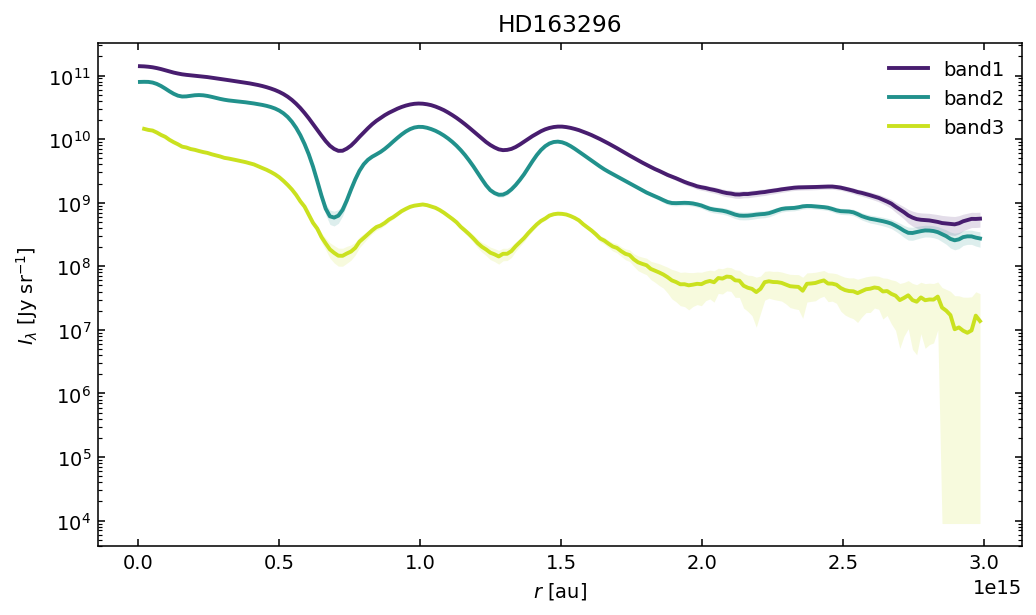

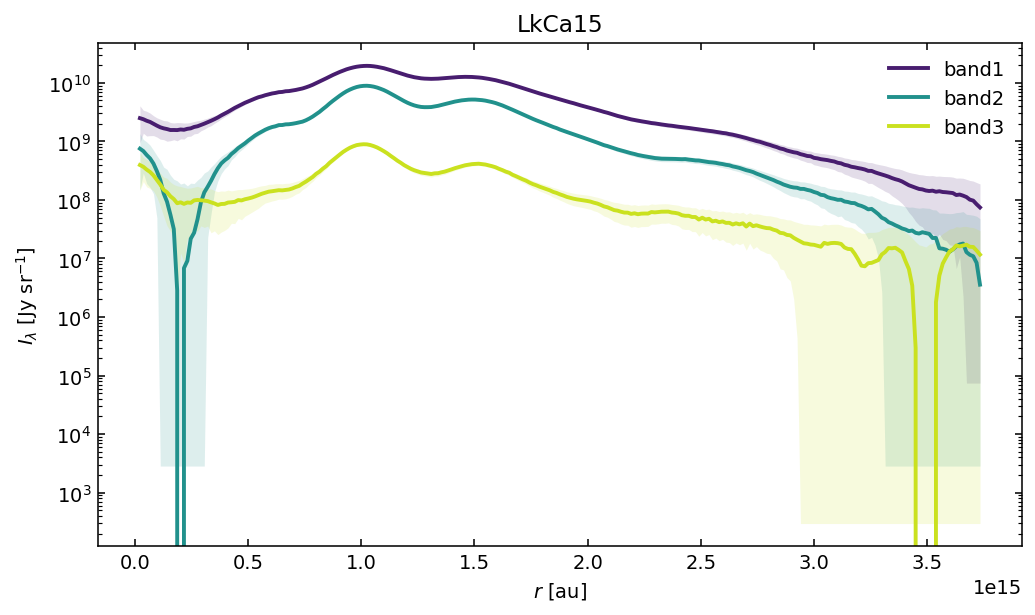

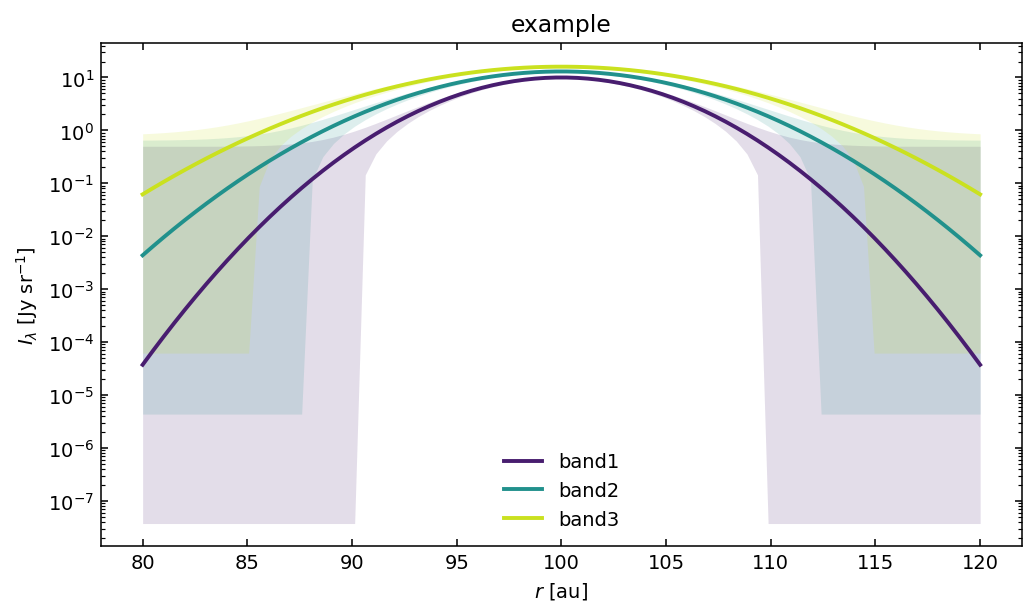

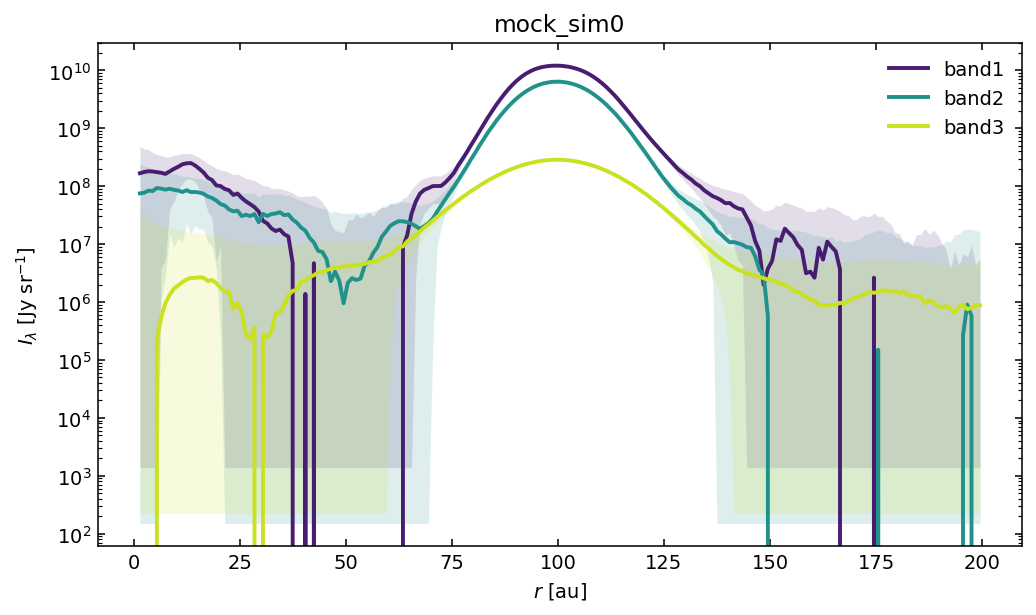

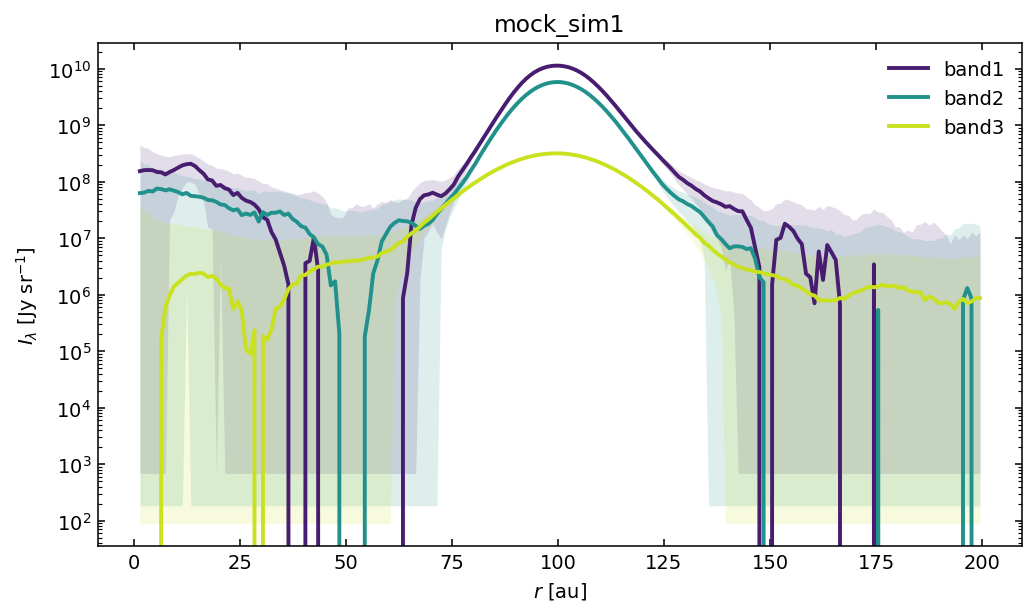

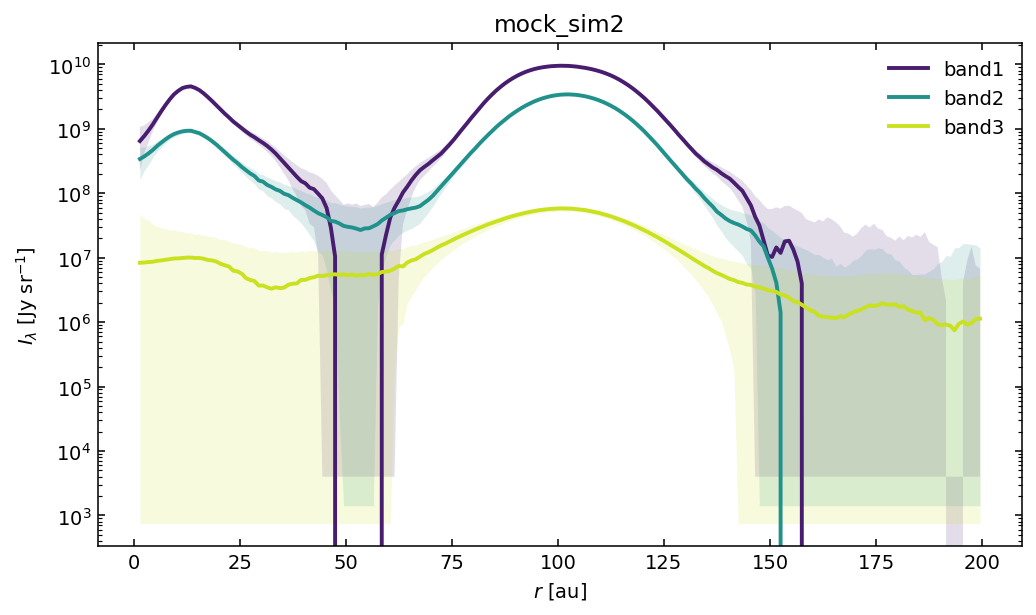

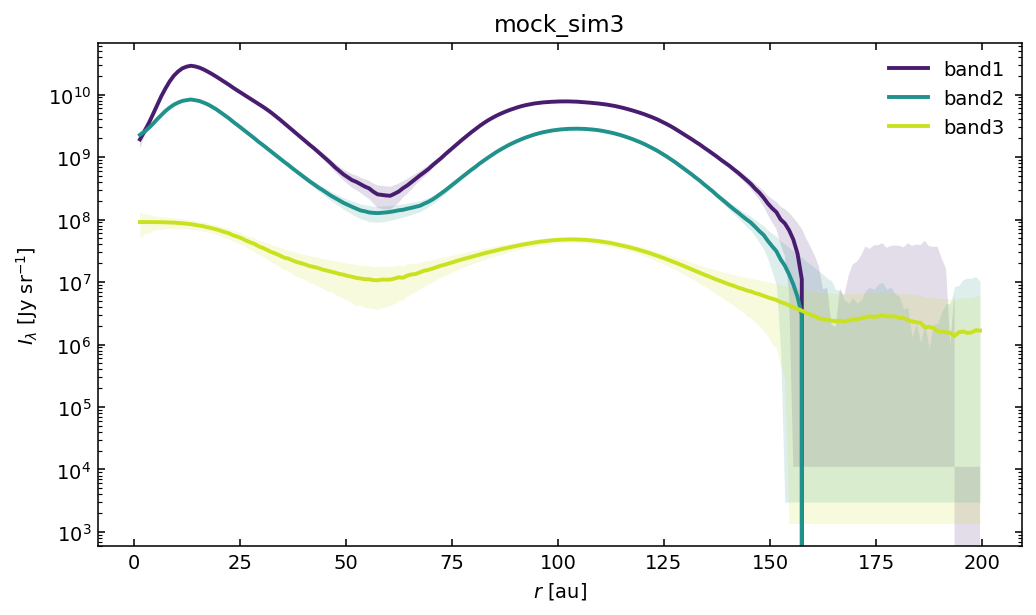

In [2]:
groups = {}
for path in sorted(DATA.glob("*_band*.npz")):
    stem = path.stem.split("_band")[0]
    groups.setdefault(stem, []).append(path)

for name, paths in groups.items():
    fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=140)
    colors = plt.get_cmap("viridis")(np.linspace(0.08, 0.92, len(paths)))
    for color, path in zip(colors, paths):
        z = np.load(path)
        r = z["radius"]
        y = z["intensity"]
        e = z["rms_error"]
        label = path.stem.replace(name + "_", "")
        floor = np.nanmin(y[y > 0]) * 1e-3 if np.any(y > 0) else 1e-99
        ax.plot(r, y, color=color, lw=2, label=label)
        ax.fill_between(r, np.maximum(y - e, floor), y + e, color=color, alpha=0.15, lw=0)
    ax.set_title(name)
    ax.set_xlabel(r"$r\ [\mathrm{au}]$")
    ax.set_ylabel(r"$I_\lambda\ [\mathrm{Jy\ sr^{-1}}]$")
    ax.set_yscale("log")
    ax.legend(frameon=False)
    ax.tick_params(direction="in", which="both", top=True, right=True)
    fig.tight_layout()
    plt.show()

## Split opacity arrays

The opacity interface is split into six fields: `size_opac`, `lam_opac`, `k_abs_opac`, `k_sca_opac`, `g_sca_opac`, and `rhos_opac`.

In [3]:
OP = DATA / "default_opacity_dsharp"
size_opac = np.load(OP / "size_opac.npy")
lam_opac = np.load(OP / "lam_opac.npy")
k_abs_opac = np.load(OP / "k_abs_opac.npy")
k_sca_opac = np.load(OP / "k_sca_opac.npy")
g_sca_opac = np.load(OP / "g_sca_opac.npy")
rhos_opac = np.load(OP / "rhos_opac.npy")

print("size_opac", size_opac.shape, "cm")
print("lam_opac", lam_opac.shape, "cm")
print("k_abs_opac", k_abs_opac.shape)
print("k_sca_opac", k_sca_opac.shape)
print("g_sca_opac", g_sca_opac.shape)
print("rhos_opac", rhos_opac)

size_opac (200,) cm
lam_opac (210,) cm
k_abs_opac (200, 210)
k_sca_opac (200, 210)
g_sca_opac (200, 210)
rhos_opac 1.675278


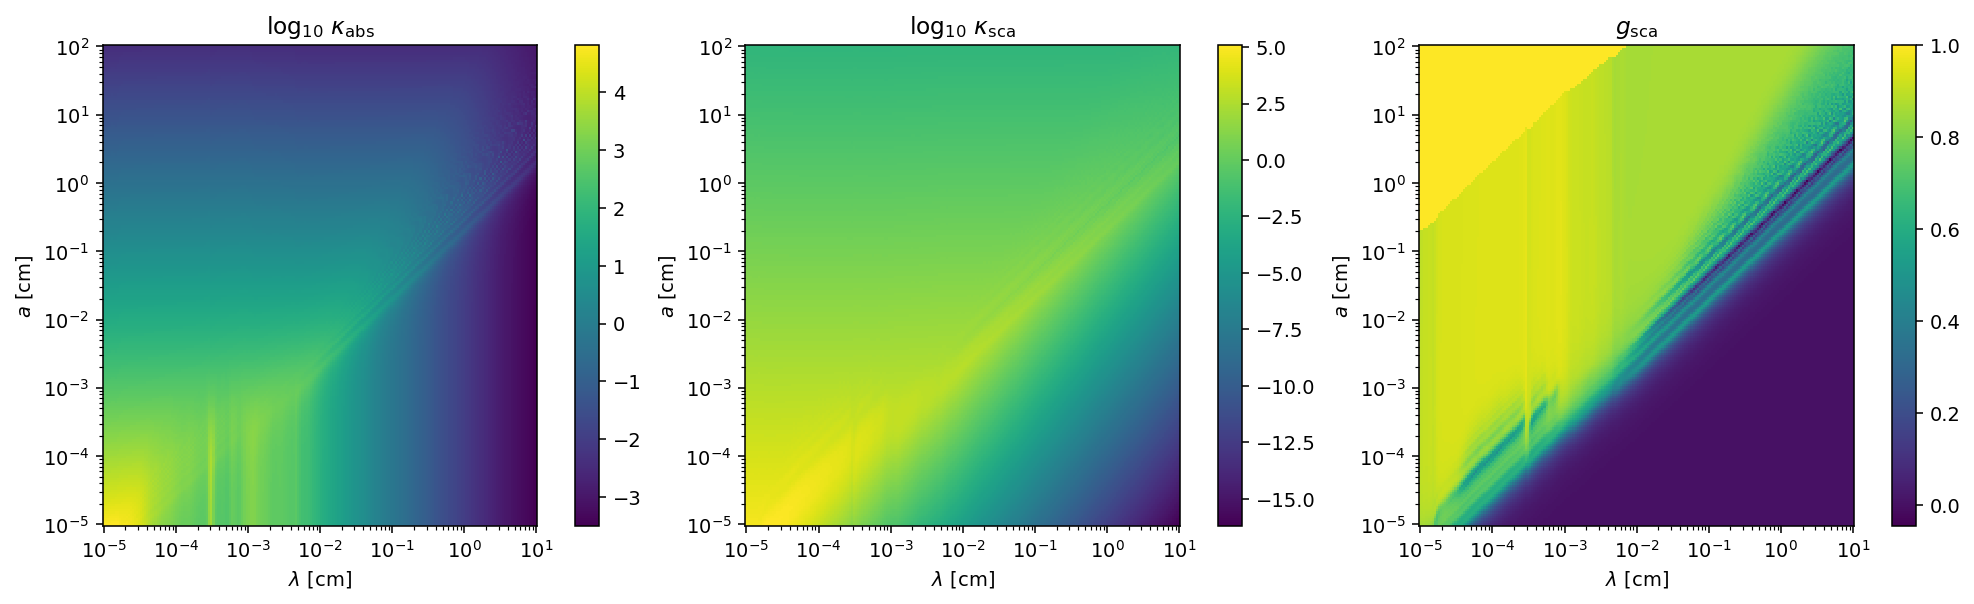

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), dpi=140, constrained_layout=True)
fields = [
    (k_abs_opac, r"$\log_{10}\,\kappa_{\rm abs}$"),
    (k_sca_opac, r"$\log_{10}\,\kappa_{\rm sca}$"),
    (g_sca_opac, r"$g_{\rm sca}$"),
]
for ax, (field, label) in zip(axes, fields):
    value = field if label.startswith("$g") else np.log10(np.maximum(field, 1e-300))
    mesh = ax.pcolormesh(lam_opac, size_opac, value, shading="auto", cmap="viridis")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$\lambda\ [\mathrm{cm}]$")
    ax.set_ylabel(r"$a\ [\mathrm{cm}]$")
    ax.set_title(label)
    fig.colorbar(mesh, ax=ax)
plt.show()